In [2]:
import numpy as np
import matplotlib.pyplot as plt

Problem 1

Pokaż, że suma dwóch (lub ogólniej – większej liczby) zmiennych normalnych
nie musi mieć rozkładu normalnego.

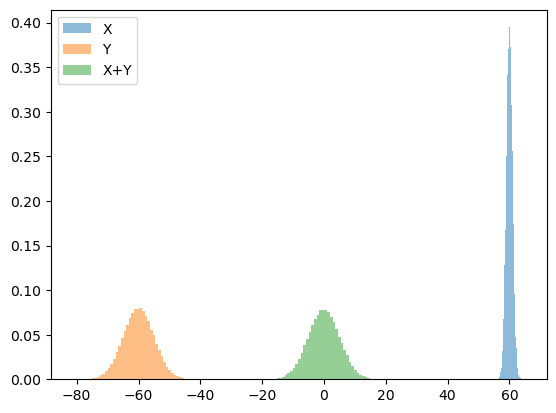

In [3]:
X = np.random.normal(loc=60, scale=1, size=100000)
Y = np.random.normal(loc=-60, scale=5, size=100000) 
XandY = X + Y

plt.hist(X, bins=50, density=True, alpha=0.5, label='X')
plt.hist(Y, bins=50, density=True, alpha=0.5, label='Y')
plt.hist(XandY, bins=50, density=True, alpha=0.5, label='X+Y')
plt.legend()
plt.show()

Problem 2

(Symulacja rozkładu α-stabilnego). Przygotuj program, który symuluje próbkę
o symetrycznym rozkładzie α-stabilnym S(α, β, γ, δ; 0) oraz S(α, β, γ, δ; 1) zdefiniowanych w
definicjach Def. 1.7 oraz Def. 1.8 w Rozdziale 1.

In [4]:
def genZ(alpha, beta, theta, W):
  if alpha == 1: 
    Z = (2/np.pi) * (((np.pi/2)+beta*theta)*np.tan(theta) - beta*np.log((np.pi/2)*W*np.cos(theta)/((np.pi/2)+beta*theta)))
  else:
    theta0 = np.arctan(beta*np.tan(np.pi*alpha/2))/alpha
    Z = (np.sin(alpha*(theta0 + theta))/((np.cos(alpha*theta0)*np.cos(theta))**(1/alpha))) * ((np.cos(alpha*theta0 + (alpha - 1)*theta)/W)**((1-alpha)/alpha))
  return Z

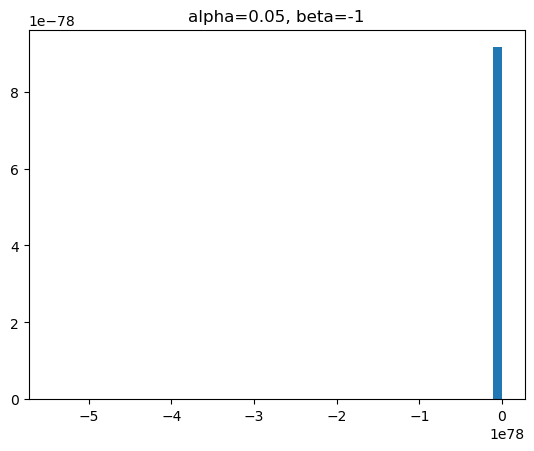

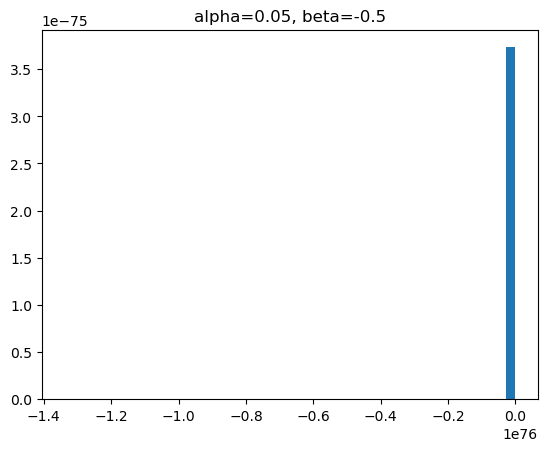

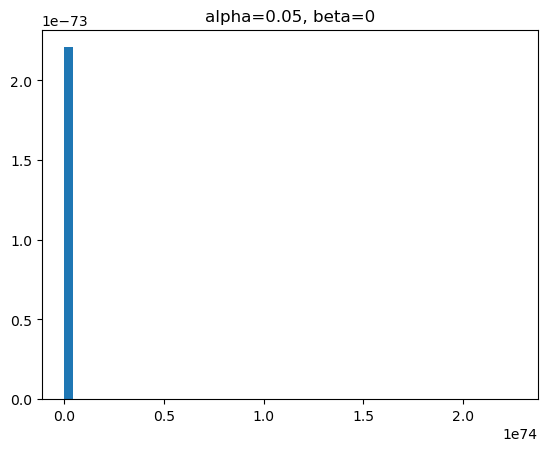

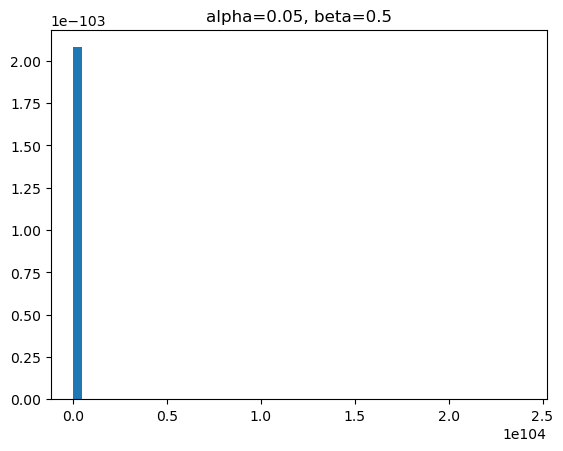

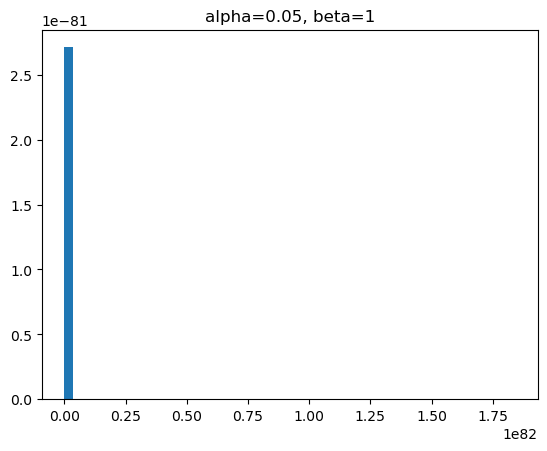

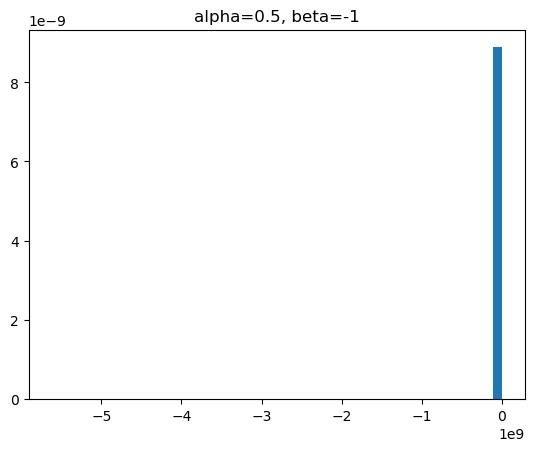

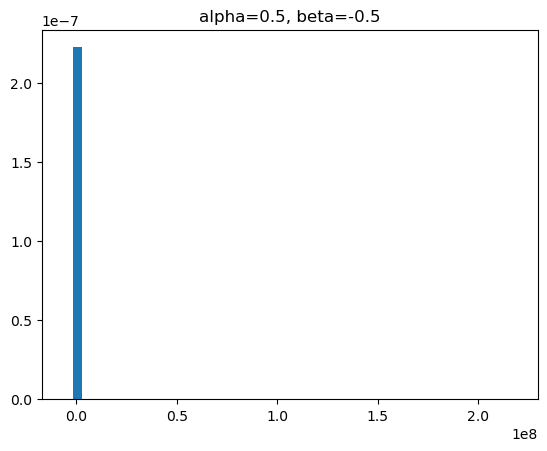

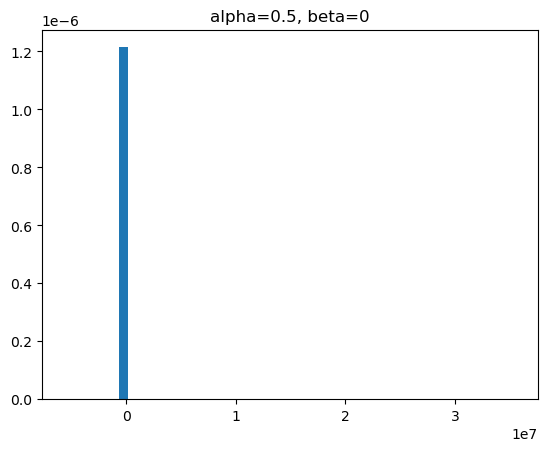

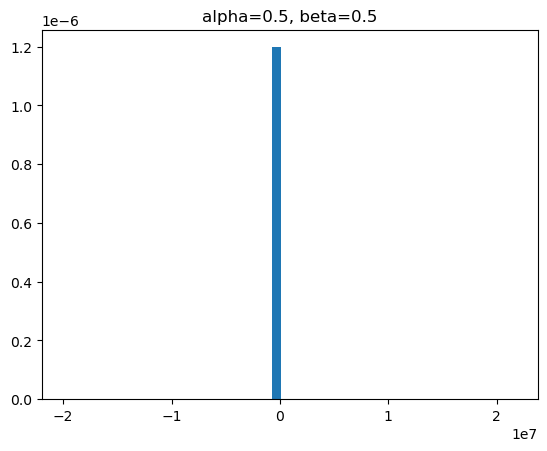

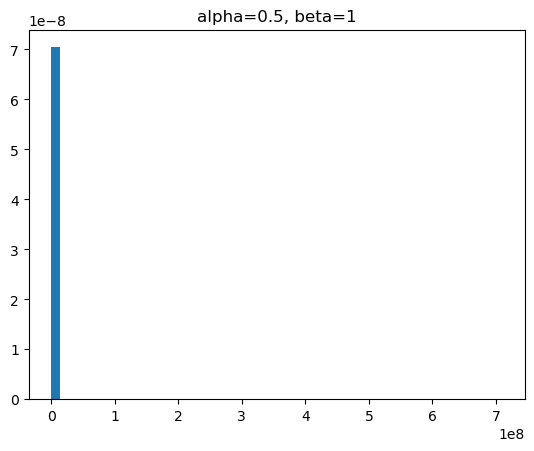

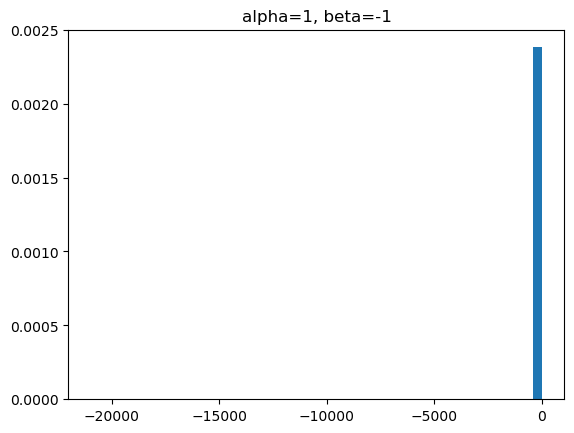

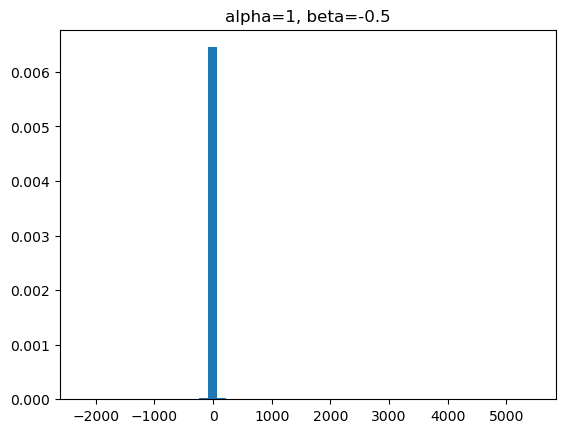

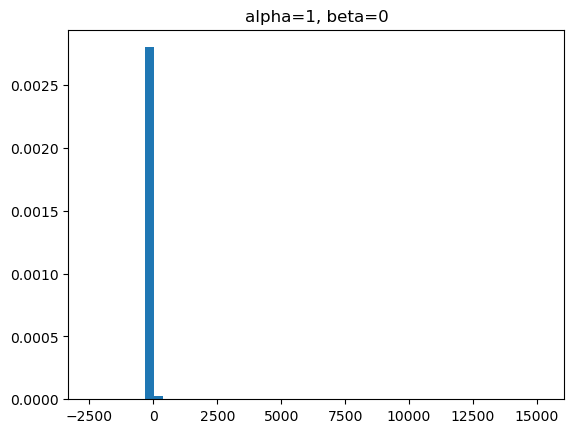

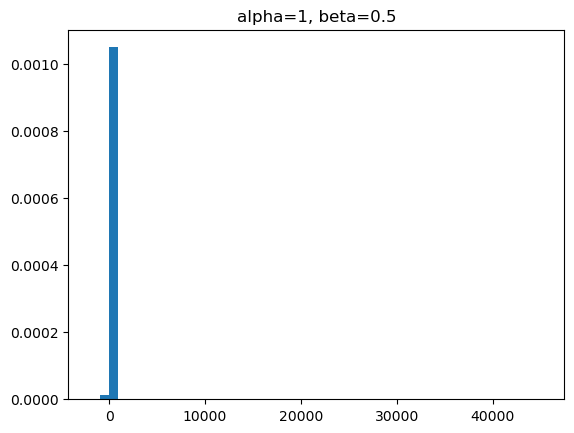

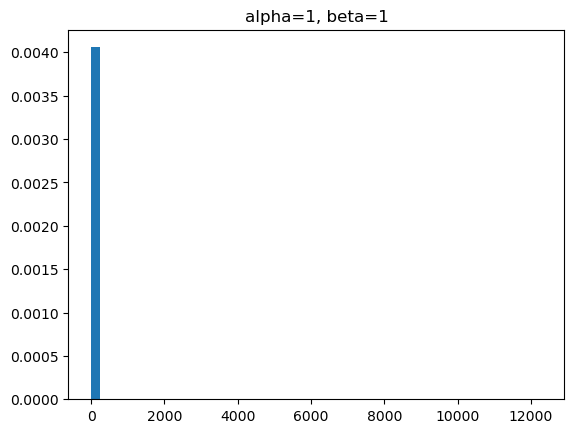

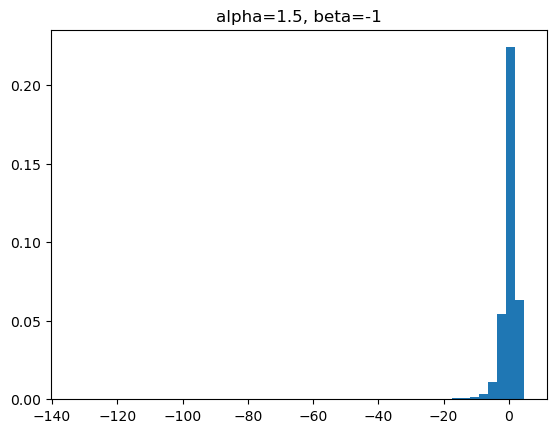

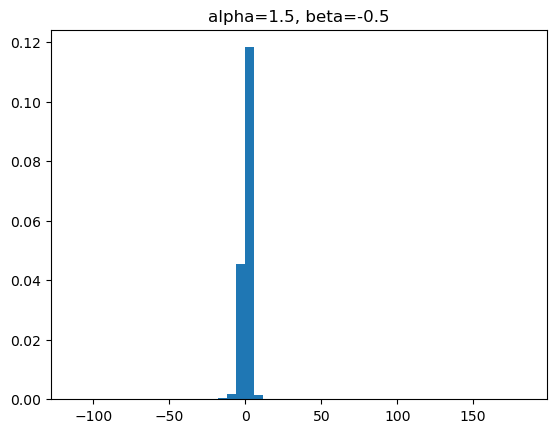

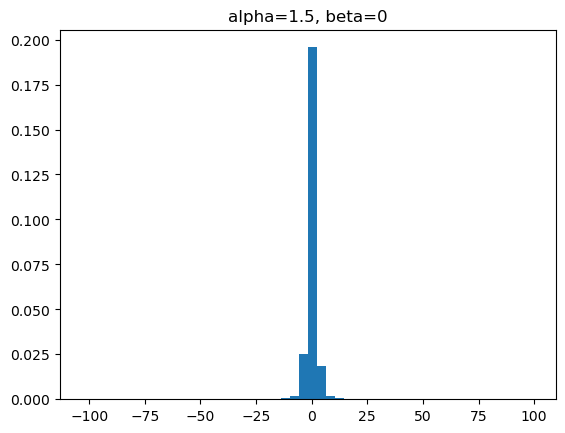

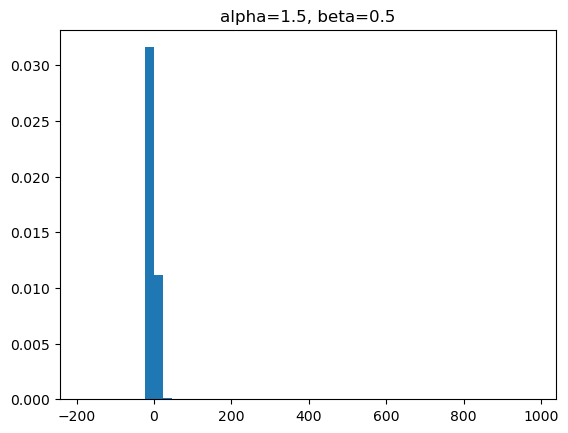

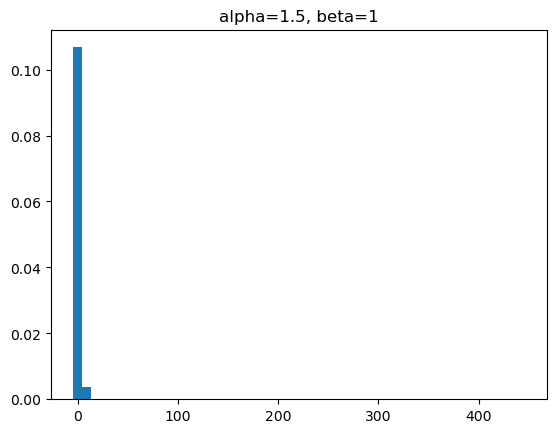

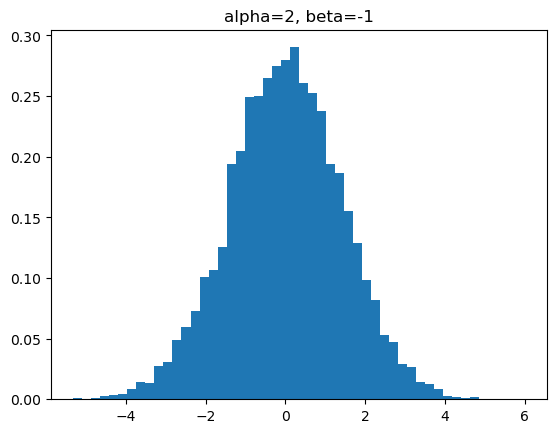

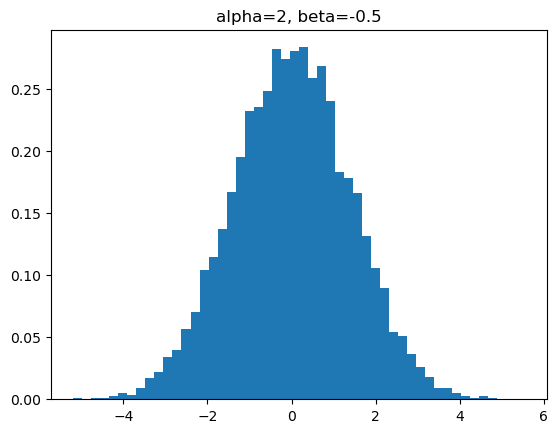

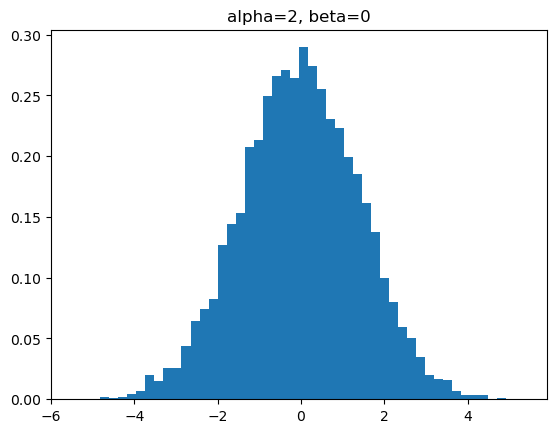

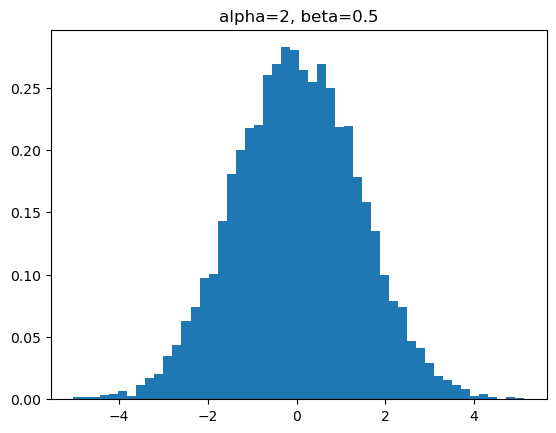

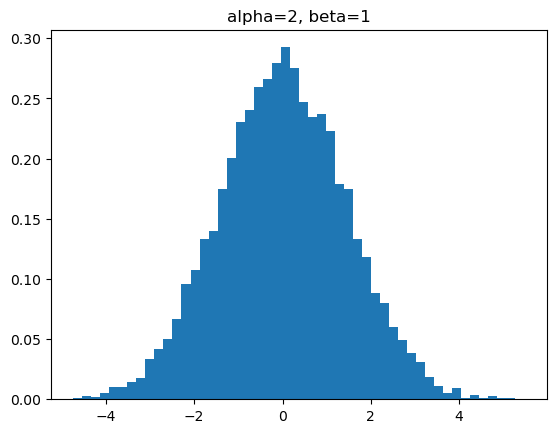

In [5]:
Ztable = []
alphaBetaZ = []

for alpha in [0.05, 0.5, 1, 1.5, 2]:
  for beta in [-1, -0.5, 0, 0.5, 1]:
    for i in range(10000):
      theta = np.random.uniform(-np.pi/2, np.pi/2)
      W = np.random.exponential(1)
      Z = genZ(alpha, beta, theta, W)
      Ztable.append(Z)
    alphaBetaZ.append((alpha, beta, Ztable))
    Ztable = []
  
for alpha, beta, Z in alphaBetaZ:
  plt.hist(Z, bins=50, density=True)
  plt.title(f'alpha={alpha}, beta={beta}')
  plt.show()

In [6]:
def S(alpha, beta, gamma, delta, zeroOne, Z):
  if zeroOne == 0:
    if alpha == 1:
      X = gamma*Z + delta
    else:
      X = gamma*(Z-beta*np.tan(np.pi/2*(alpha))) +delta
  else:
    if alpha == 1:
      X = gamma*Z + (delta + beta*(2/np.pi)*gamma*np.log(gamma))
    else:
      X = gamma*Z + delta
  return X

Problem 3

(Funkcja charakterystyczna symetrycznych rozkładów α-stabilnych). Porów-
naj empiryczną funkcję charakterystyczną obliczoną dla próbek z symetrycznego rozkładu α-
stabilnego (β = 0, δ = 0) z jej dokładną postacią
α
φX (t) = e−c|t| ,
t∈R
dla pewnego c ≥ 0 (jak parametr c jest powiązany z pozostałymi parametrami rozkładu α-
stabilnego?).
Jak można w prosty sposób wyjaśnić, że dla symetrycznego rozkładu α-stabilnego funkcja
charakterystyczna nie posiada części urojonej?

Ss mean: -177.1961097621777
Zz mean: -177.1961097621777


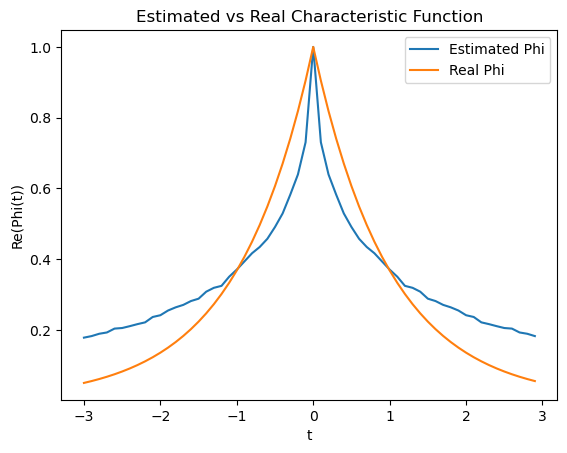

In [7]:
def estPhi(t,X):
  N = len(X)
  phi = 0
  for x in X:
    phi += np.exp(1j*t*x) 
  return phi/N

def realPhi(t,c,alpha):
  return np.exp(-c*np.abs(t)**alpha)
 

alpha = 0.5
beta = 0.0
gamma = 1
delta = 0
Ss = np.array([])
Zz = np.array([])

for i in range(10000):

  theta = np.random.uniform(-np.pi/2, np.pi/2)
  W = np.random.exponential(1)
  Z = genZ(alpha, beta, theta, W)
  S_value = S(alpha, beta, gamma, delta, 1, Z)
  Ss = np.append(Ss, S_value)
  Zz = np.append(Zz, Z)

print("Ss mean:", np.mean(Ss))
print("Zz mean:", np.mean(Zz))

phis = []
for t in np.arange(-3.0, 3.0, 0.1):
  ePhi = estPhi(t, Ss)
  rPhi = realPhi(t, 1, 1)
  phis.append((t, ePhi, rPhi))


#Y axis - real phi, X axis - estimated phi
plt.plot([t for t, ePhi, rPhi in phis], [np.real(ePhi) for t, ePhi, rPhi in phis], label='Estimated Phi')
plt.plot([t for t, ePhi, rPhi in phis], [np.real(rPhi) for t, ePhi, rPhi in phis], label='Real Phi')
plt.title('Estimated vs Real Characteristic Function')
plt.xlabel('t')
plt.ylabel('Re(Phi(t))')
plt.legend()
plt.show()

#za 2 tyg kart. opisz znaczenie param w rozkladnie alpha stabilnym, beta, gamma, delta, zeroOne

Problem 4

(Porównanie gęstości dla znanych przypadków). Dla przypadków:
1. rozkład normalny,
2. rozkład Cauchy’ego,
3. rozkład Lévy’ego,
znajdź odpowiednie parametry rozkładu α-stabilnego. Następnie porównaj estymowane gęsto-
ści (oraz, jeśli to możliwe, dystrybuanty) z ich analitycznymi odpowiednikami przedstawio-
nymi w uwagach 1 − 3.

Problem 5

(Ogon dystrybuanty i gęstości). Korzystając z symulacji Monte Carlo pokaż,
że dla X ∼ S(α, β, γ, δ; 0) z 0 < α < 2, −1 < β ≤ 1 zachodzi następujące zachowanie dla
t → ∞:
• P(X > x) ∼ γ α cα (1 + β)t−α ,
• fX (t) ∼ αγ α cα (1 + β)t−(α+1) ,
oraz dla −1 ≤ β < 1, gdy −t → −∞:
• P(X < −t) ∼ γ α cα (1 − β)t−α ,
• fX (−t) ∼ αγ α cα (1 − β)t−(α+1) .
W obu przypadkach parametr
 απ  Γ(α)
.
cα = sin
2
π

# LISTA 2

In [8]:
import scipy.stats as stats
import math

Problem 1:
P(X > t) ~t->inf ~ a_{alhpa,gamma,beta}t^-alhpa

Idea: Rozwazyc ln P(X>t) ~ ln a_{a,g,b}-alpha*ln t
i zrobic reg. lin. ln P(X > t) =y_k = c_0 + c_1*x_k + eps, gdzie x_k = ln t_k,
c_0 = ln a_{a,g,b}, c_1 = -alpha

Zacząć od narysowania:
OY = ln P(X>t) = ln (1-F(t))
OX = ln t

linia prosta y = c_0 + c_1 x''

interesują nas duże t; t_k = 10% najw; ecdf - empirical cumulative dist. fun.

przykladowe x ~ S(a=1.2,gamma=1,beta=0,delta=0)

ecdf = #{X_i:X_i<=t}/N

t = [X_{1:N},...,X_{N:N}]

lnt: [       nan        nan        nan ... 6.05452983 6.15110823 6.54047967]


/tmp/ipykernel_50401/268431954.py:18: RuntimeWarning: invalid value encountered in log
  lnt = np.log(t)
/tmp/ipykernel_50401/268431954.py:19: RuntimeWarning: divide by zero encountered in log
  lnfdce = np.log(1 - fdce.cdf.probabilities)


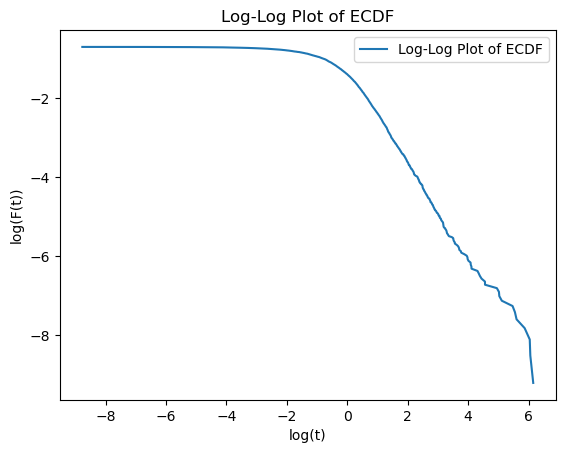

top10percentlnt: [0.91652401 0.91770256 0.92098152 0.92280175 0.92325003 0.92338342
 0.924992   0.92585748 0.92627405 0.9282685  0.92829934 0.93329866
 0.9334251  0.93391991 0.93419143 0.93492049 0.93566469 0.93606798
 0.93648245 0.93653268 0.93700713 0.93712148 0.93726928 0.93791628
 0.93845681 0.93866302 0.9408394  0.9416723  0.94373724 0.94709225
 0.94810757 0.94821799 0.94963181 0.94988714 0.95142587 0.95194081
 0.95300556 0.95379153 0.95401594 0.95554987 0.95623234 0.95880183
 0.95896196 0.95976271 0.96096518 0.96116148 0.96184886 0.96244787
 0.96412451 0.96720119 0.9675361  0.96756125 0.96900723 0.97053754
 0.97095531 0.97182207 0.97249804 0.97272587 0.97654332 0.97713221
 0.97766121 0.97780264 0.98064733 0.98087845 0.98224777 0.98557168
 0.9878973  0.98796507 0.98862871 0.98916924 0.98946059 0.98951243
 0.99053986 0.99175943 0.99242575 0.9924607  0.99391587 0.99435022
 0.99596565 0.99625998 0.99642863 0.99763939 0.99809829 0.99817615
 0.99845491 0.99888838 0.99939107 1.00042566 

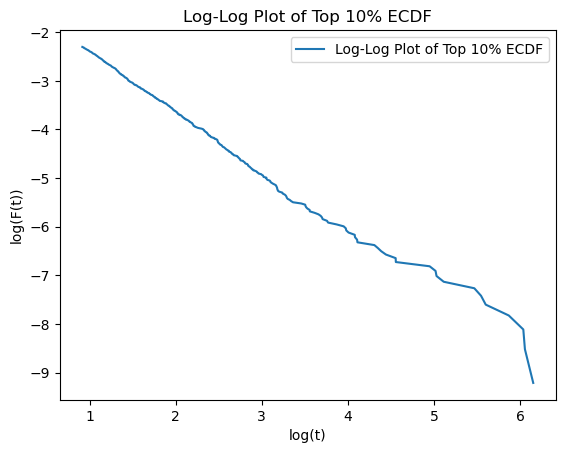

In [9]:
alpha = 1.2
beta = 0.0
gamma = 1
delta = 0

t = np.array([])
for i in range(10000):
  theta = np.random.uniform(-np.pi/2, np.pi/2)
  W = np.random.exponential(1)

  Z = genZ(alpha, beta, theta, W)
  x = S(alpha, beta, gamma, delta, 0, Z)
  t = np.append(t, x)

t = np.sort(t)
fdce = stats.ecdf(t)

lnt = np.log(t)
lnfdce = np.log(1 - fdce.cdf.probabilities)

print("lnt:", lnt)

plt.plot(lnt, lnfdce, label='Log-Log Plot of ECDF')
plt.title('Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

len_t = len(t)
top10percentlnt = lnt[int(0.9*len_t):]
top10percentlnfdce = lnfdce[int(0.9*len_t):]

print("top10percentlnt:", top10percentlnt)

plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Log-Log Plot of Top 10% ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

c_0: 0.43661518275890926
c_1: -1.2


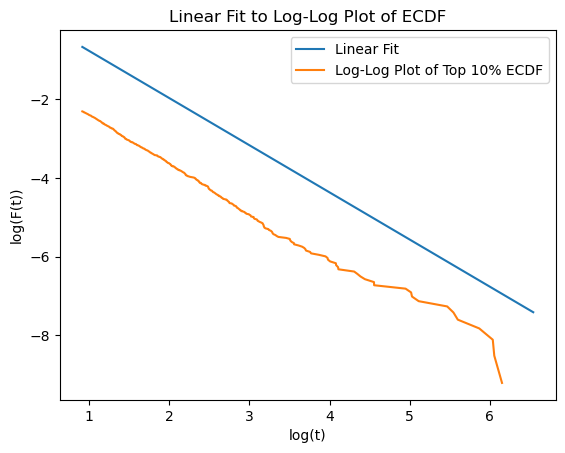

In [10]:
y = np.array([])
# c_0 = top10percentlnfdce + alpha * top10percentlnt
# c_0 = 0
c_0 = np.sin(alpha*np.pi/2) * math.gamma(alpha)/2
# c_0 = -1
c_1 = -alpha

print("c_0:", c_0)
print("c_1:", c_1)

for i in range(9000, 10000):
  x_i = top10percentlnt[i-9000]
  y_i = c_0 + c_1 * x_i
  y = np.append(y, y_i)

plt.plot(top10percentlnt, y, label='Linear Fit')
plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Linear Fit to Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

Problem 2: estymacja funkcji charakterystycznej

X ~ S_alpaha S to phi_x(t) = e^{-gamma^alpha |t|^alpha}
Stąd ln phi_x(t) = gamma^alhpa *|t|^alpha
y_k = ln |ln (est_phi_x(t_k))| = ln(gamma^alpha) + alpha ln|t_k|

x_k = ln|t_k|

c_0: 0.43661518275890926
c_1: -1.2


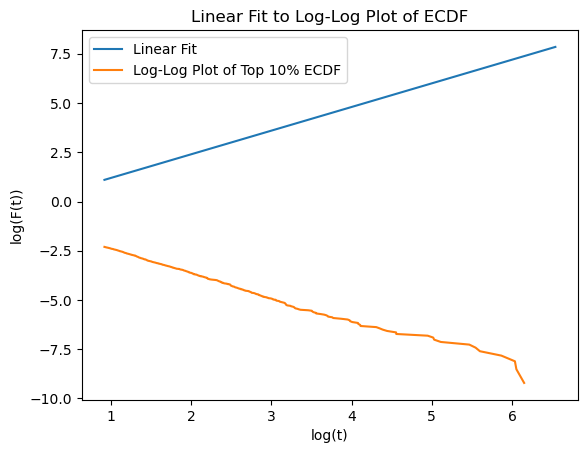

In [11]:
y = np.array([])
# c_0 = top10percentlnfdce + alpha * top10percentlnt
# c_0 = 0
c_0 = np.sin(alpha*np.pi/2) * math.gamma(alpha)/2
# c_0 = -1
c_1 = -alpha

print("c_0:", c_0)
print("c_1:", c_1)

for i in range(9000, 10000):
  x_i = top10percentlnt[i-9000]
  y_i = np.log(gamma**alpha) + alpha * x_i
  y = np.append(y, y_i)

plt.plot(top10percentlnt, y, label='Linear Fit')
plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Linear Fit to Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

znaczenie param w rozkladnie alpha stabilnym:
- alpha: stability parameter, determines the tail behavior of the distribution. For alpha < 2, the distribution has heavy tails. For alpha = 2, it reduces to a normal distribution. 

co jak jeden rapm jest wiekszy niz drugi, co jak w jednej probie beta = 1 a w drgije 0

# LISTA 3

P(eps_i = 1) = 1/2 = P(eps_i = -1)

Gamma_i = sum_k=1^i e_k

e_k ~iid~ Exp(1)

X = sum_i=1^N=inf eps_i*Gamma_i^{-1/alpha}*W_i ~ S_alpha(B=0,mi=0,sigma=(c__alhpa * (Expected|W|^alpha)^1/alpha))

for 0 <alhpa <2

In [60]:
def genEps(n):
  return np.array([np.random.choice([-1, 1]) for _ in range(n)])

def genTime(n):
  ekas = np.array([np.random.exponential(1) for _ in range(n)])
  gammas = np.array([0] * (n))
  gamma = 0
  for i in range(n):
    gamma += ekas[i]
    gammas[i] = gamma
  print(f"Generated gammas: {gammas}")
  return gammas

def genW(n):
  # return np.array([np.random.poisson(1) for _ in range(n)])
  return np.array([np.random.uniform(0, 1) for _ in range(n)])

def genSumX(n, alpha):
  epsilons = genEps(n)
  gammas = genTime(n)
  W = genW(n)
  X = np.array([0]*n)
  for i in range(n):
    print(f"i={i}, epsilons[i]={epsilons[i]}, gammas[i]={gammas[i]}, W[i]={W[i]}")
    X[i] = epsilons[i] * (gammas[i] ** (-1/alpha)) * W[i]
  return X

In [ ]:
N = 100000


In [61]:
#real X for W = uniform(0,1)

for alpha in [0.5, 1, 1.5, 1.9]:
  expectedAbsWi = 1/(alpha+1)
  cAlpha = np.sin(np.pi*alpha/2) * math.gamma(alpha) / np.pi
  gamma = (1/((alpha+1) * cAlpha))**(1/alpha)
  # gamma = 1
  # print(f"alpha={alpha}, expectedAbsWi={expectedAbsWi}, cAlpha={cAlpha}, gamma={gamma}")  
  estX = genSumX(N, alpha)
  # print(f"Generated estimated X={np.mean(estX)} for alpha={alpha}")
  
  realX = S(alpha, 0, gamma, 0, 0, genZ(alpha, 0, np.random.uniform(-np.pi/2, np.pi/2), np.random.exponential(1)))
  
  plt.hist(estX, bins=50, density=True, alpha=0.5, label='Estimated X')
  plt.title(f'EX alpha={alpha}')
  plt.legend()
  plt.show()

  # plt.hist(estX, bins=50, density=True, alpha=0.5, label='Estimated X')
  plt.hist(realX, bins=50, density=True, alpha=0.5, label='Real X')
  plt.title(f'RX alpha={alpha}')
  plt.legend()
  plt.show()

Generated gammas: [   0    0    0    1    3    4    4    5    6    8    9   10   11   11
   12   14   15   16   16   17   17   17   18   18   20   20   20   21
   21   21   22   22   22   23   24   25   26   26   28   29   30   32
   32   32   32   34   35   36   41   41   42   43   44   47   47   47
   48   48   49   49   50   50   51   52   54   54   54   56   57   58
   59   60   61   64   66   66   67   67   68   69   71   72   74   74
   77   78   80   83   84   84   86   86   87   88   88   90   95   95
   96   96   97   97   97   98  100  102  102  102  103  103  104  106
  107  108  108  110  111  113  114  116  120  121  121  121  124  124
  126  126  126  129  131  132  133  134  134  135  136  136  137  137
  137  138  138  139  140  142  143  144  144  145  146  146  147  151
  151  151  153  153  153  154  157  159  159  160  162  162  165  165
  166  166  167  168  169  169  170  171  173  173  174  174  175  176
  176  177  177  177  178  179  179  179  180  182  182  18

/tmp/ipykernel_50401/186244537.py:25: RuntimeWarning: divide by zero encountered in power
  X[i] = epsilons[i] * (gammas[i] ** (-1/alpha)) * W[i]


OverflowError: cannot convert float infinity to integer

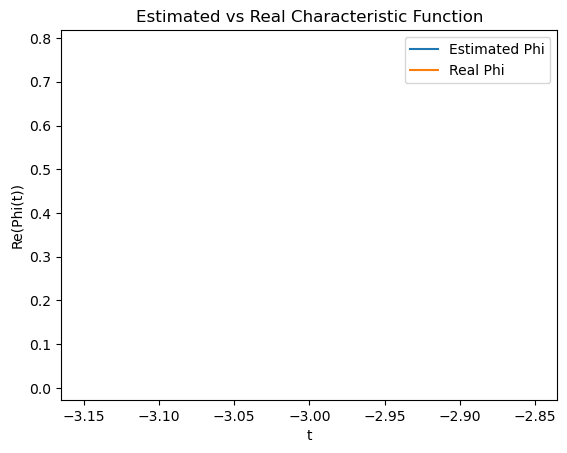

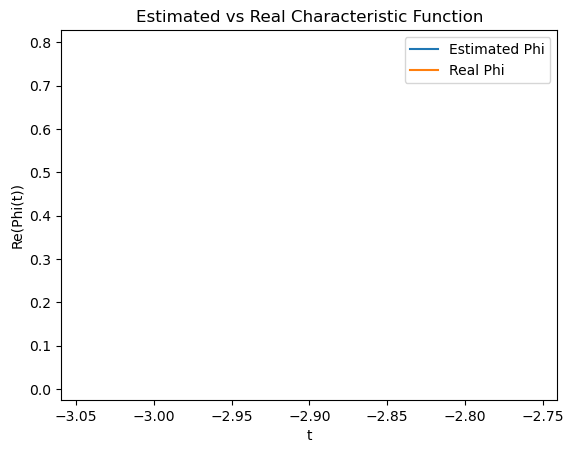

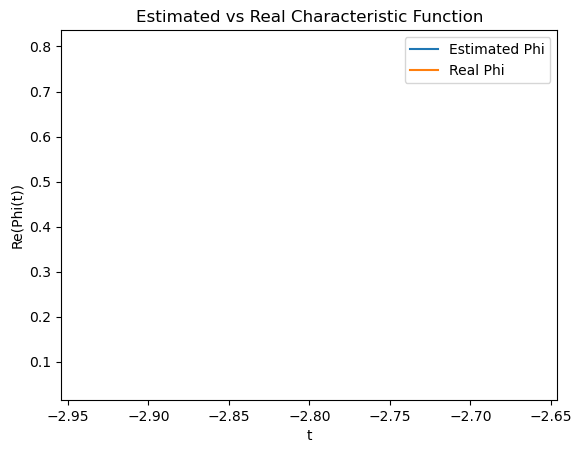

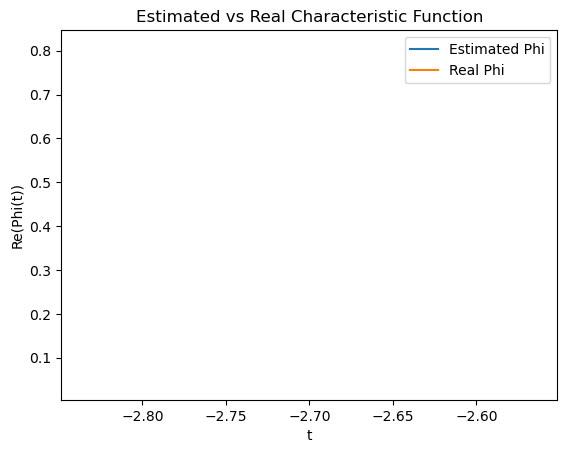

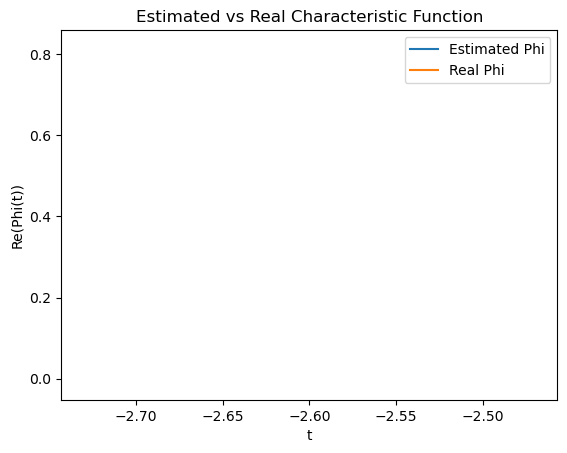

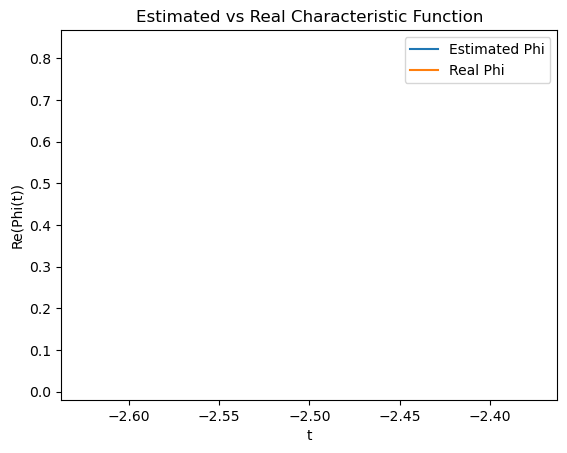

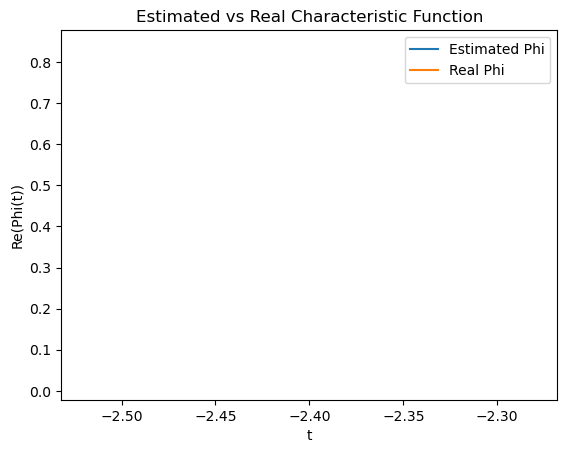

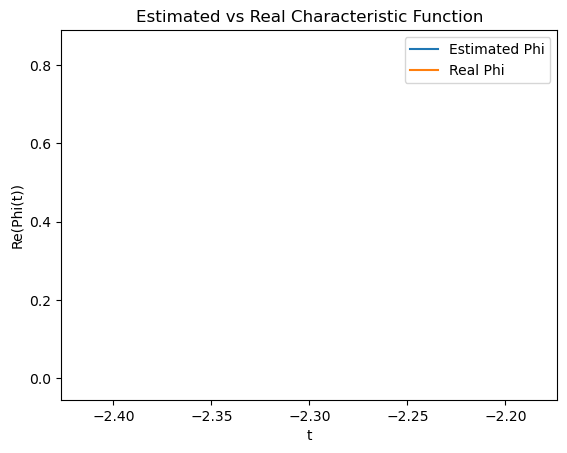

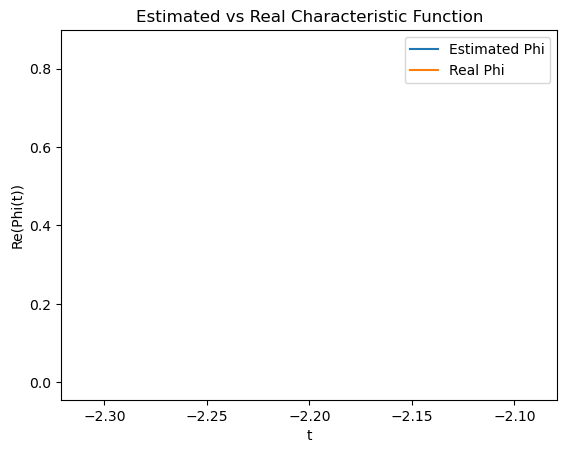

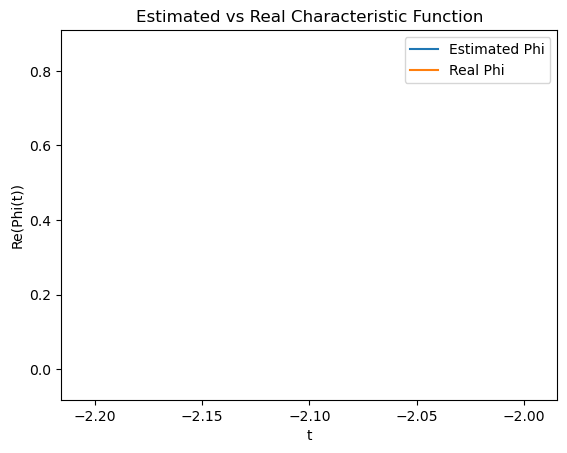

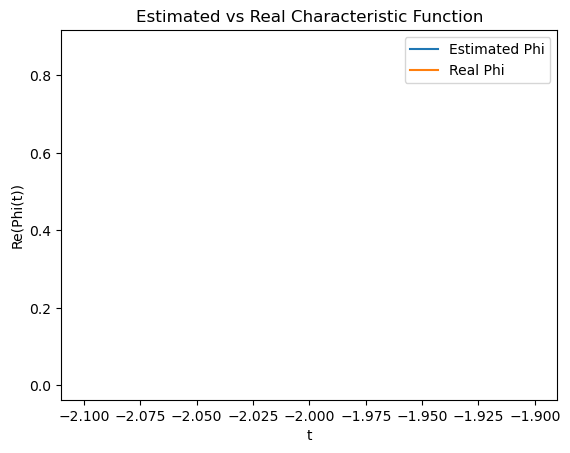

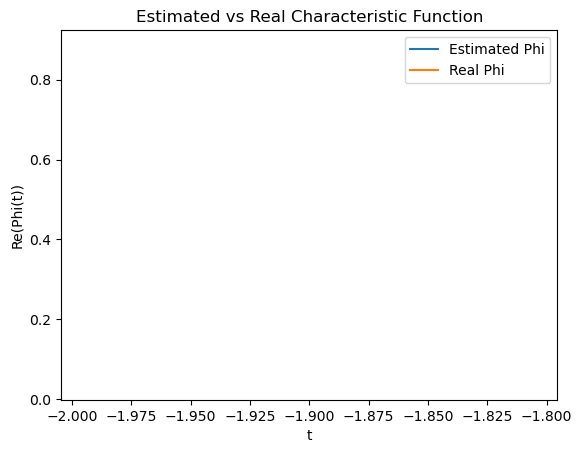

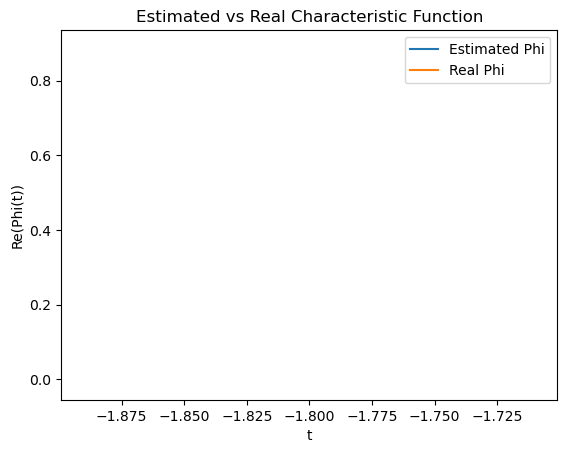

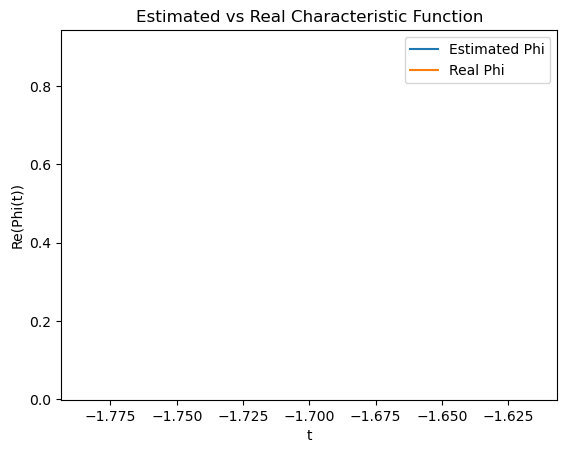

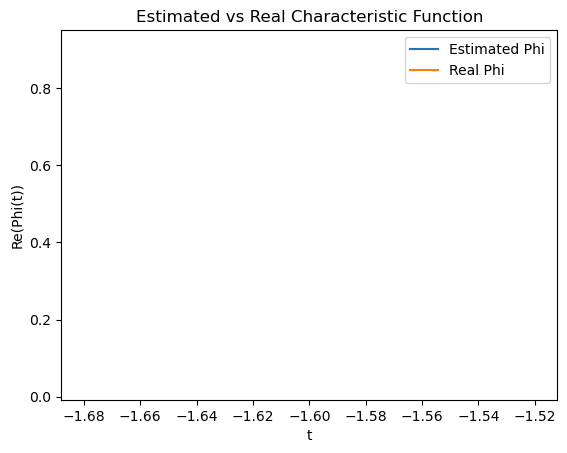

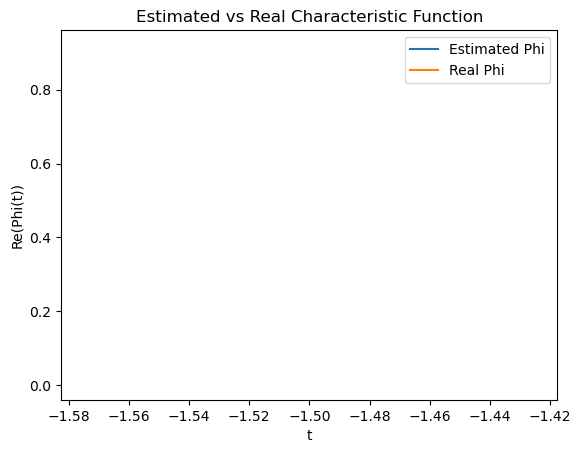

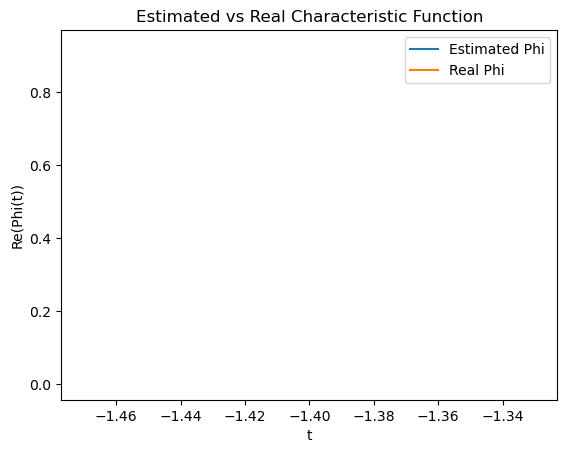

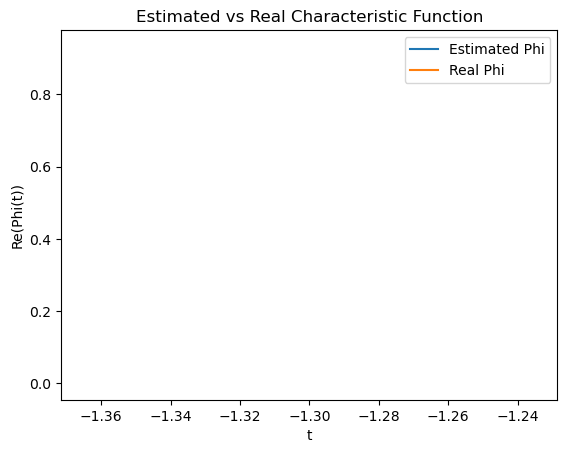

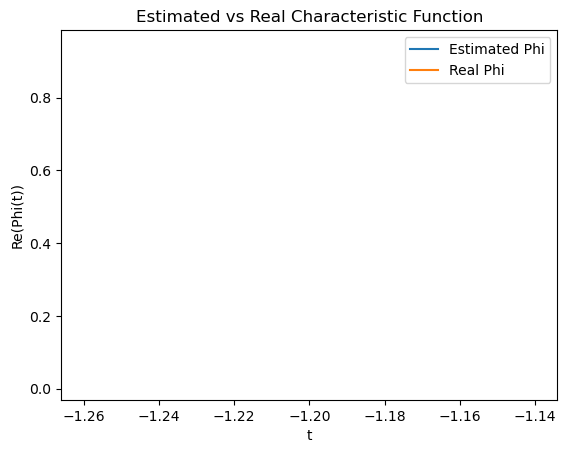

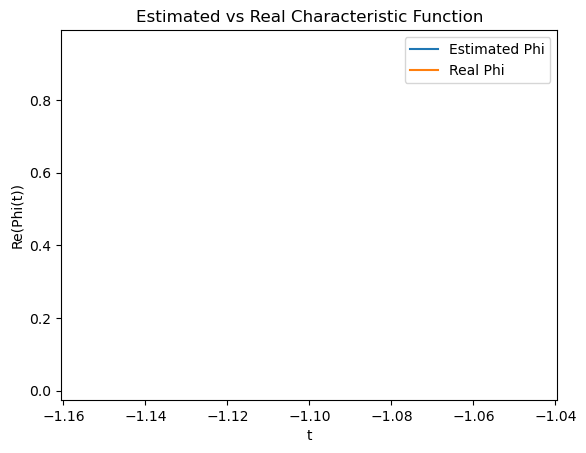

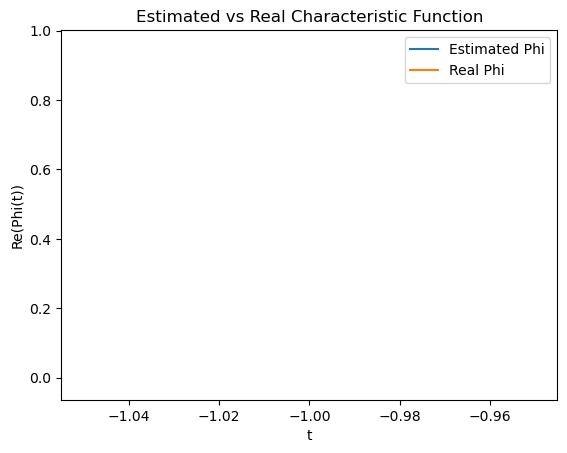

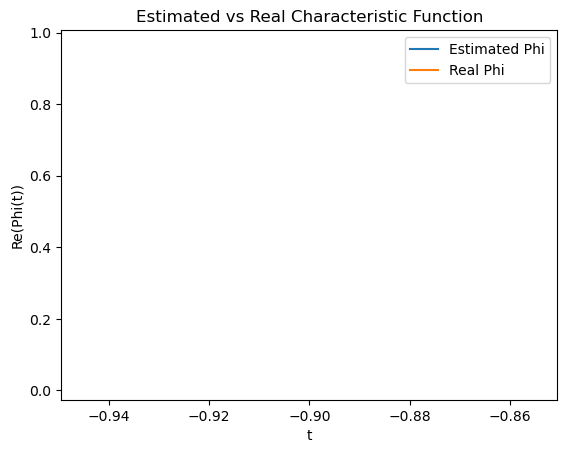

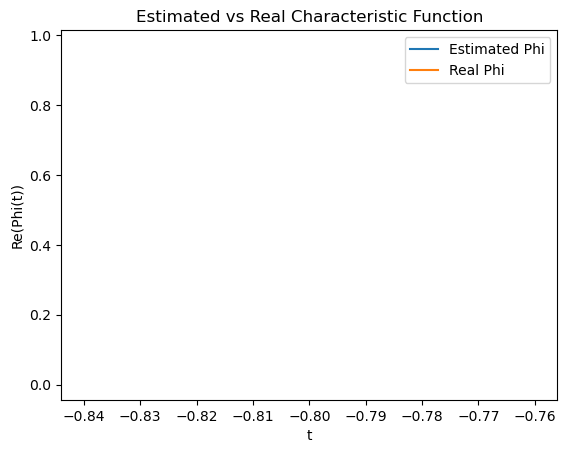

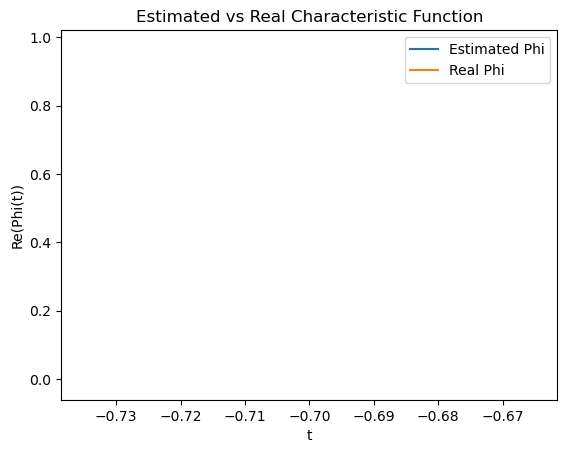

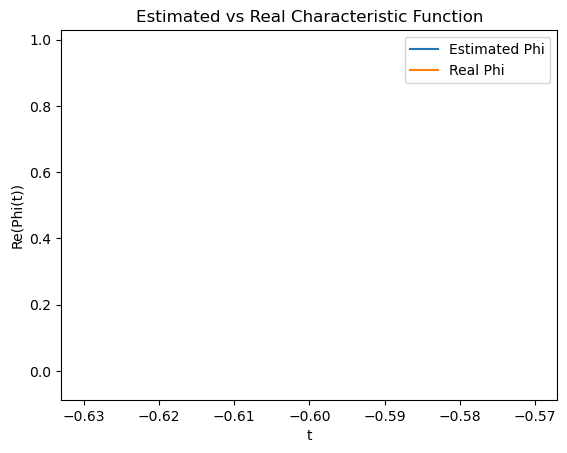

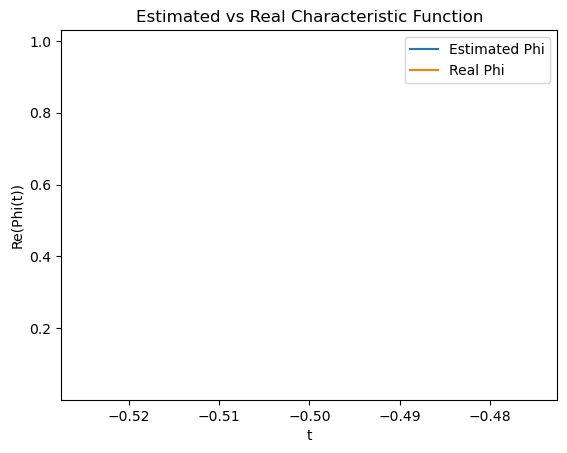

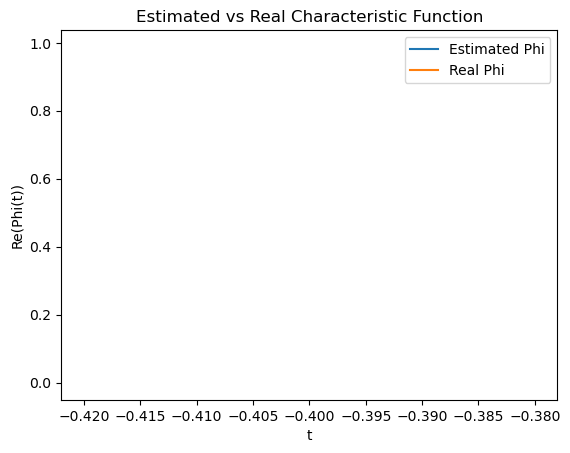

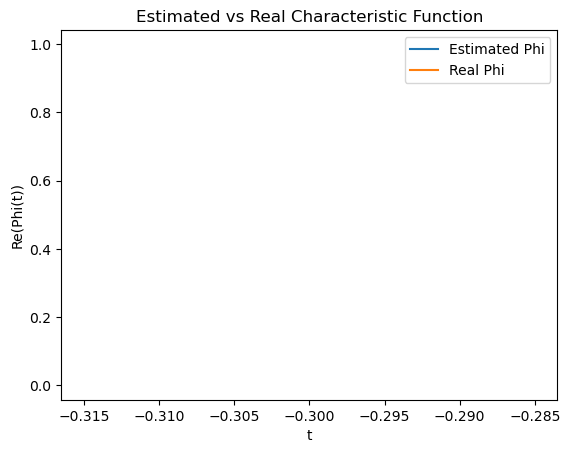

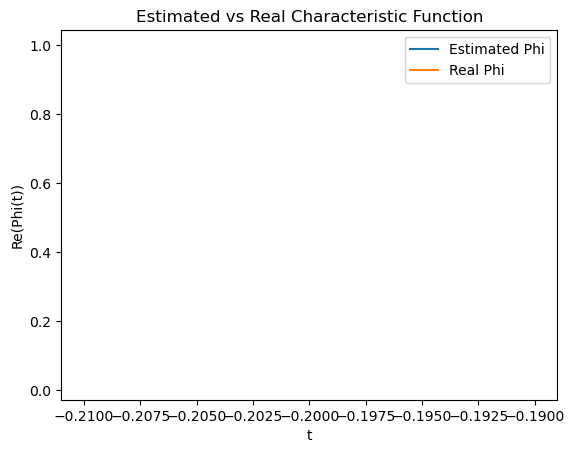

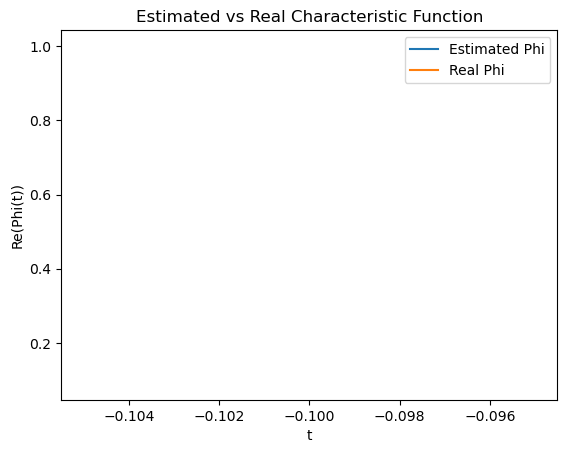

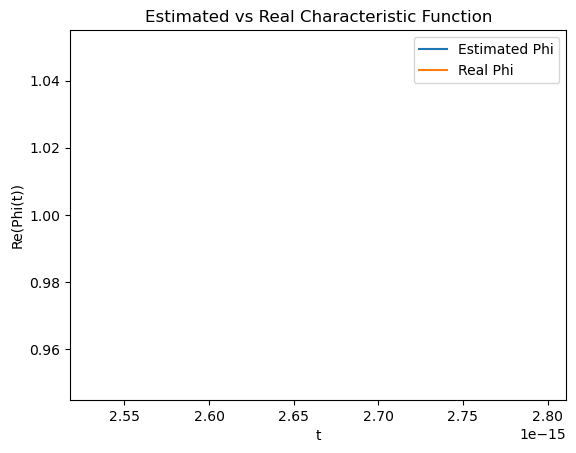

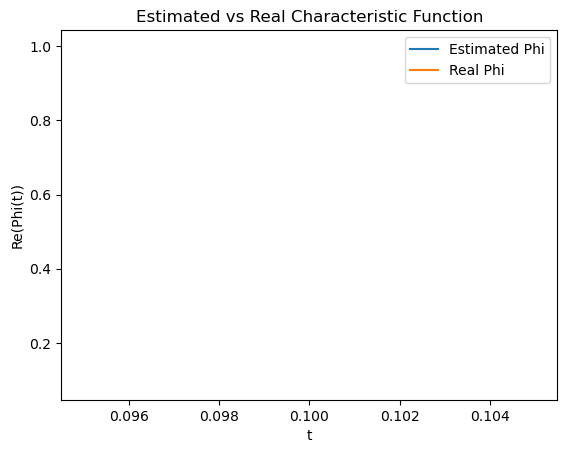

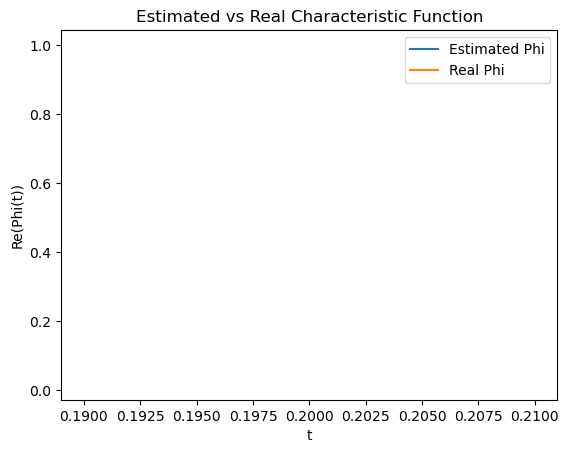

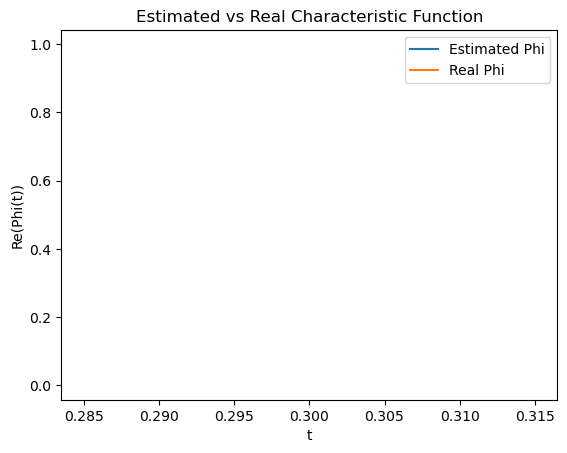

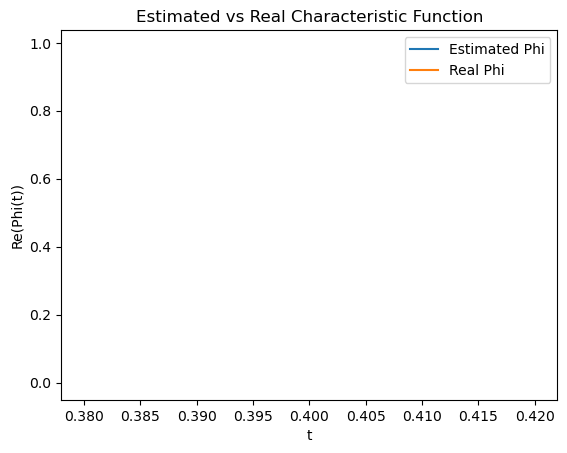

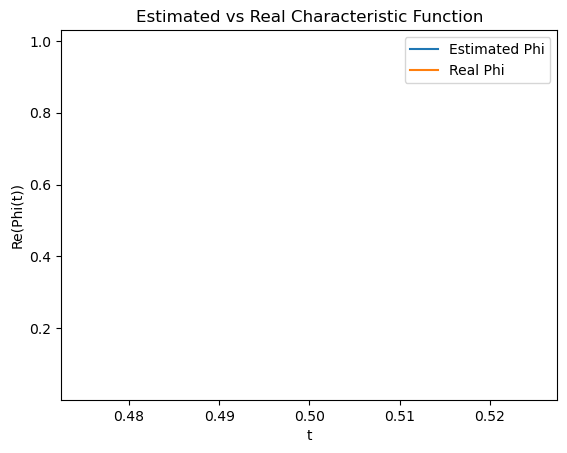

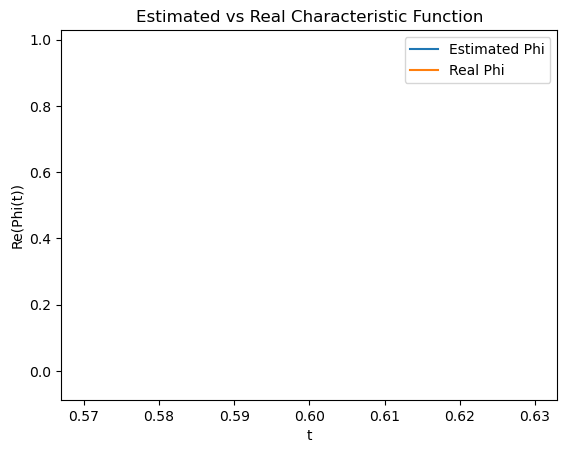

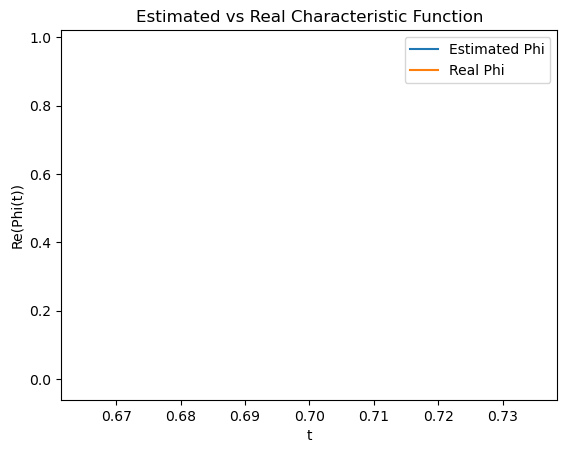

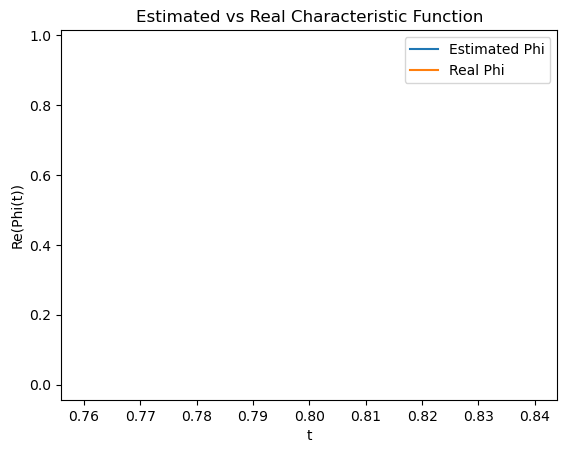

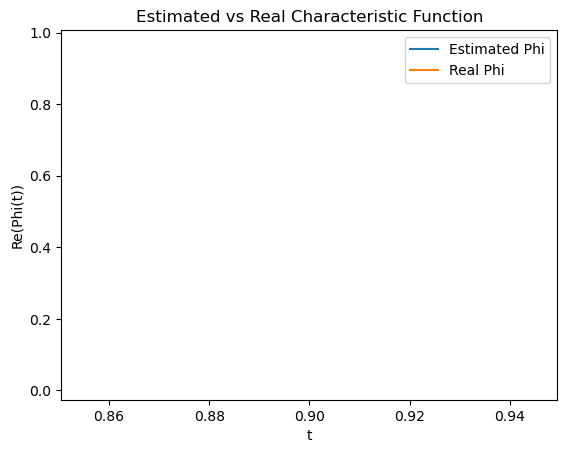

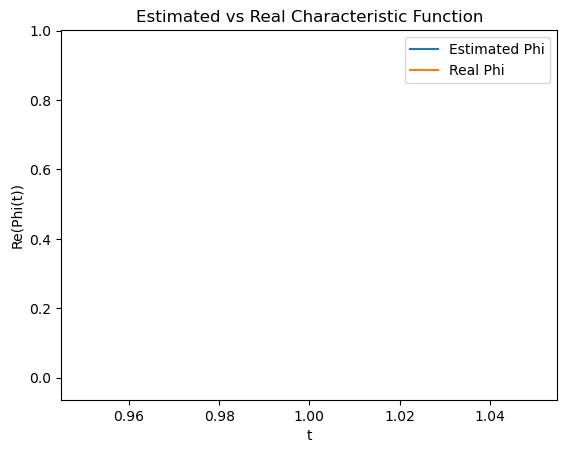

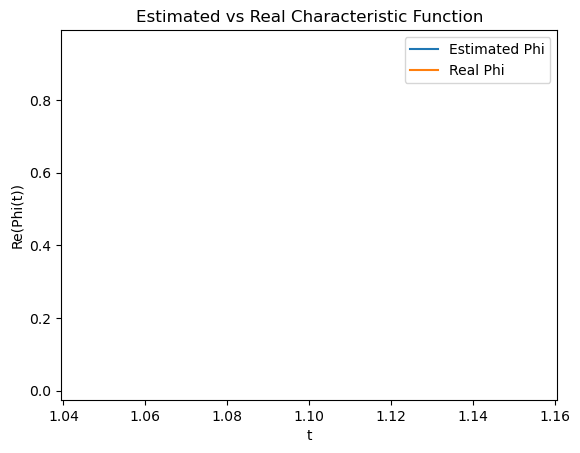

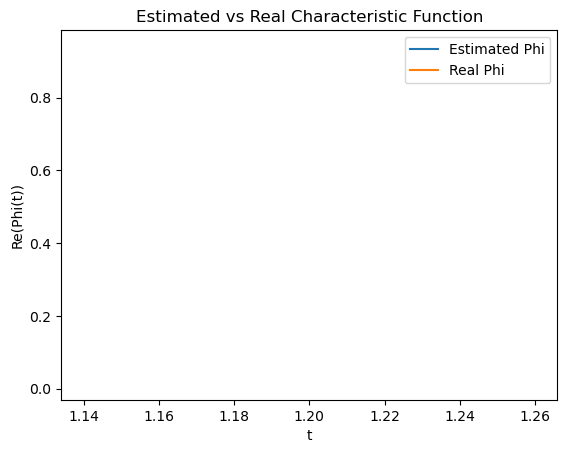

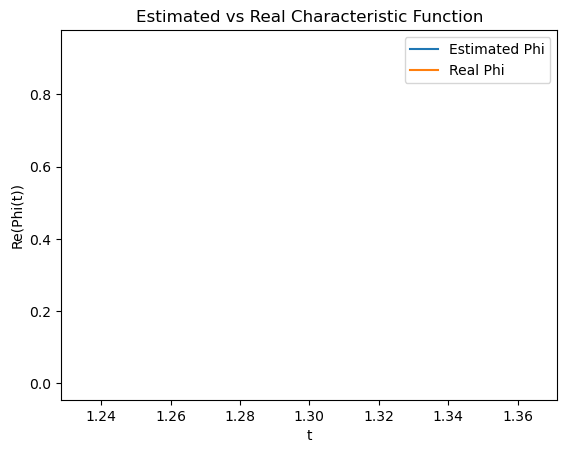

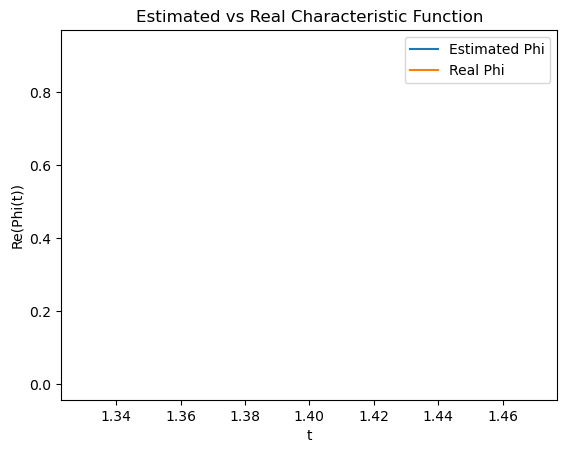

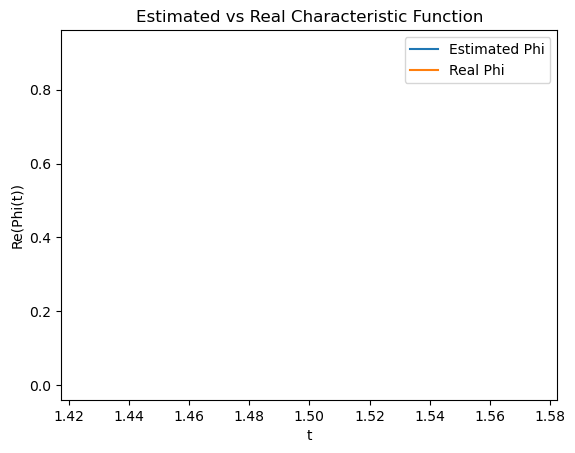

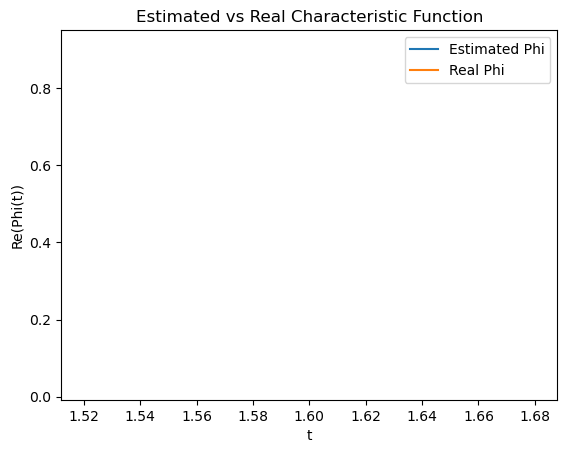

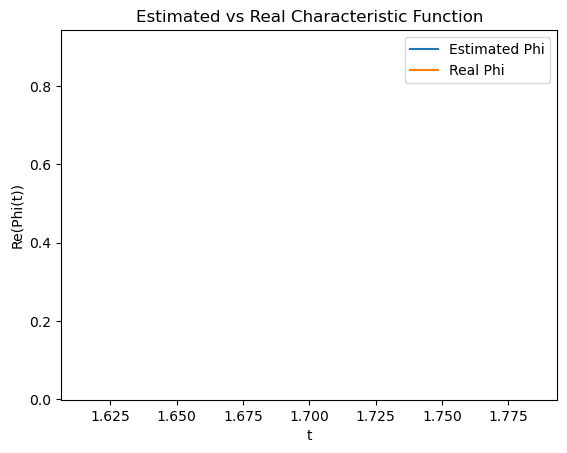

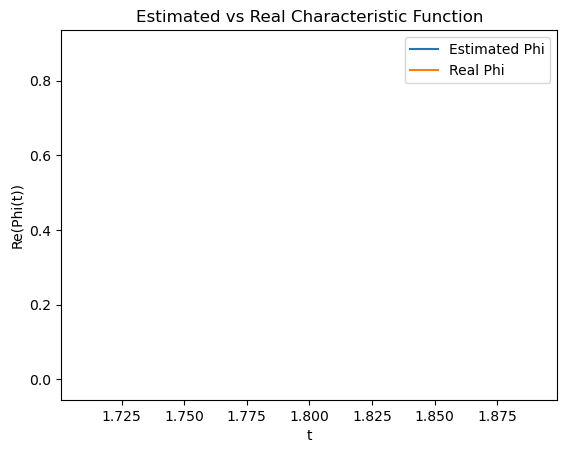

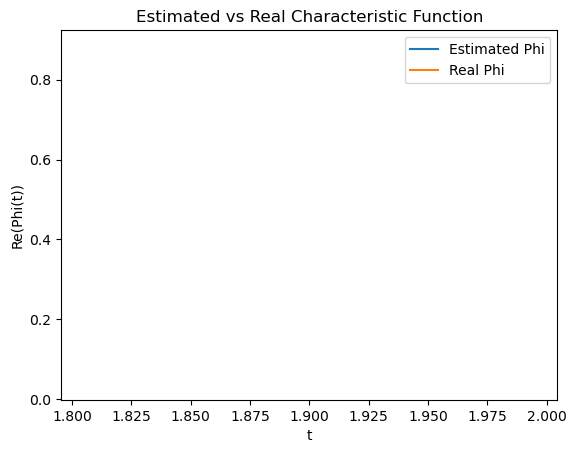

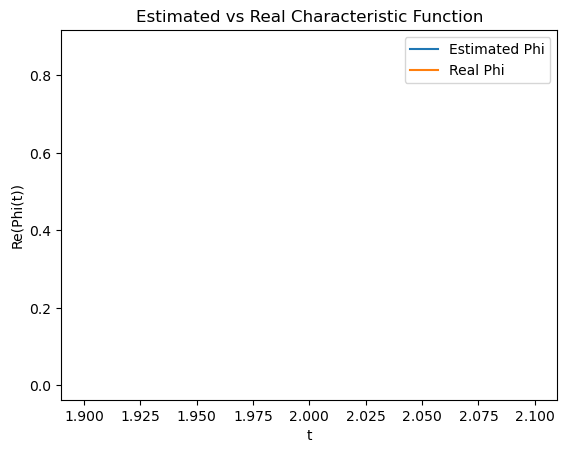

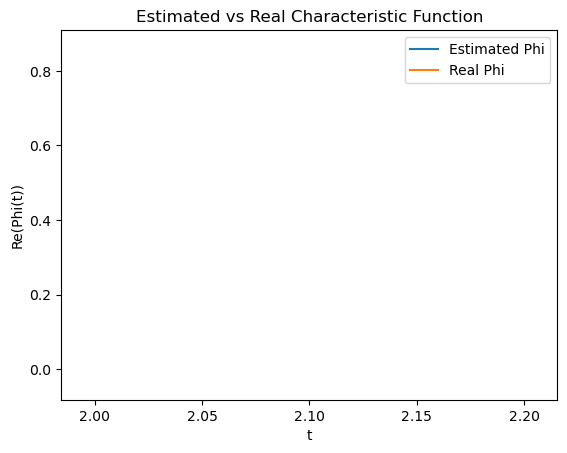

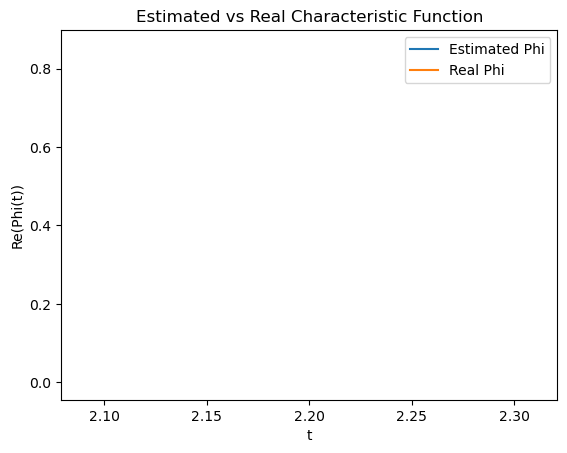

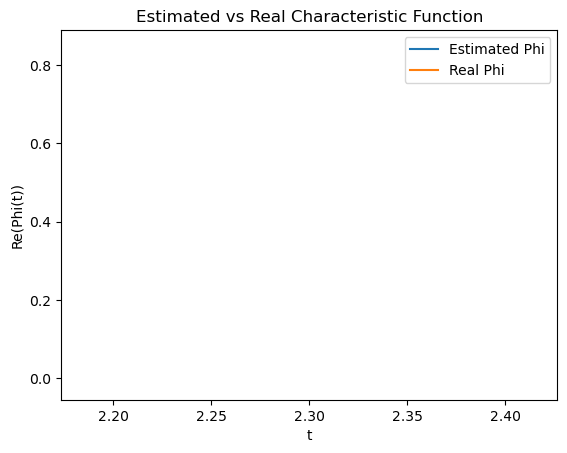

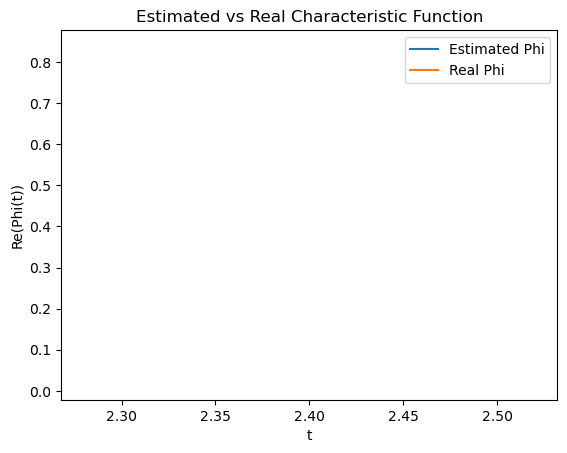

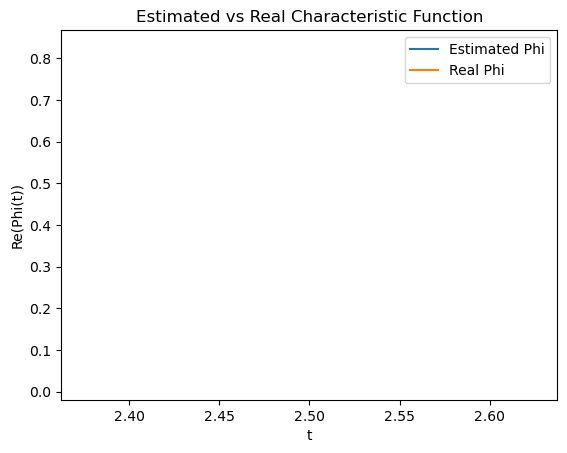

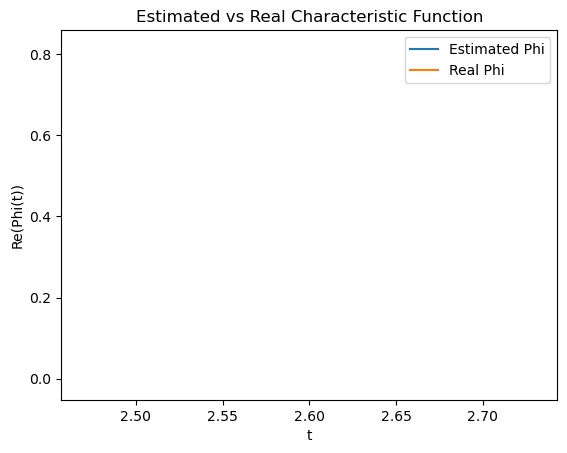

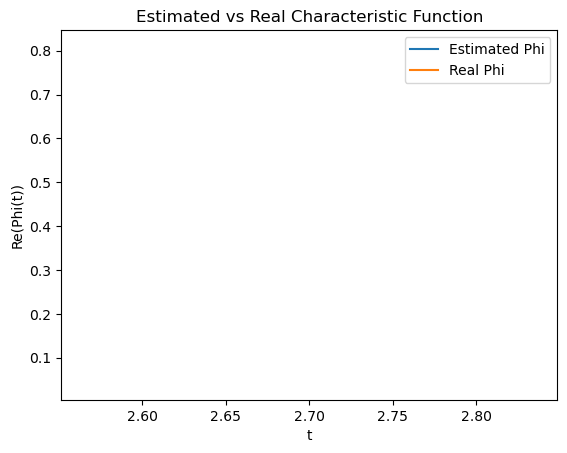

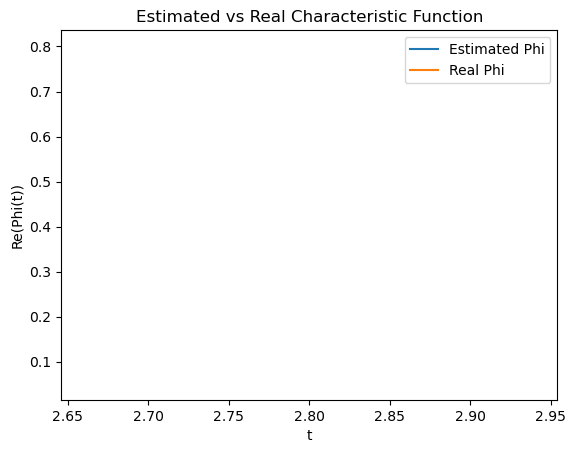

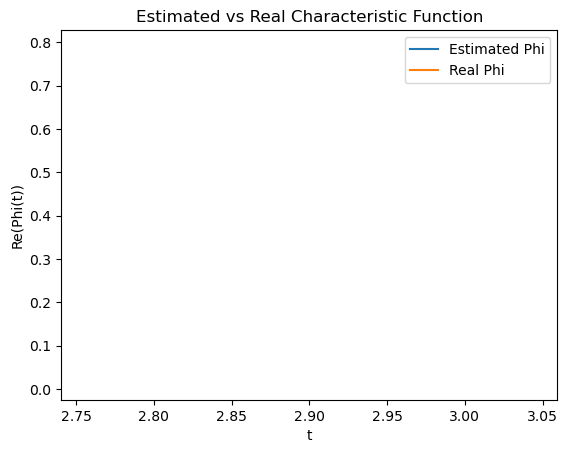

In [51]:
#plot re phi~(t) vs Im phi~(t) for alpha=1.5
alpha = 1.5
estX = genSumX(N, alpha)
for t in np.arange(-3.0, 3.0, 0.1):
  ePhi = estPhi(t, estX)
  rPhi = realPhi(t, cAlpha, alpha)
  plt.plot(t, np.real(ePhi), label='Estimated Phi')
  plt.plot(t, np.real(rPhi), label='Real Phi')
  plt.title('Estimated vs Real Characteristic Function')
  plt.xlabel('t')
  plt.ylabel('Re(Phi(t))')
  plt.legend()
  plt.show()

In [ ]:
e